In [1]:
import pandas as pd
import os
import json
import socket
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys
sys.path.append('../')
from utils_plot import plot_colors

In [159]:
lake='zug'
model = f'{lake}_2025'
with open('..//config.json', 'r') as file:
    mitgcm_config = json.load(file)[socket.gethostname()][model]

In [160]:
start_date = '2025-03-01'
end_date = '2026-03-01'

In [161]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "energy_budget")

In [162]:
seiche_folder = f'../../modal_analysis/horizontal_mode_analysis/figures/modal_decomposition/{lake}'

# Import data

In [165]:
depth_suffix = '_-0.25--56.6m'
str_depth_min = '0' #'0'
str_depth_max = '-60'

if lake=='lucerne':
    depth_suffix = '_-0.25--72.8m'
    str_depth_max = '-70'


In [166]:
total_ke = pd.read_csv(os.path.join(output_folder, f"ke_lake{depth_suffix}.csv"))
eddy_ke = pd.read_csv(os.path.join(output_folder, f"ke_eddies{depth_suffix}.csv"))
total_pe = pd.read_csv(os.path.join(output_folder, "EP_KBWinters1995.csv"))
seiche_ke = pd.read_csv(os.path.join(seiche_folder, f"KE_V1H1.csv"))
#wind_energy = pd.read_csv(os.path.join(output_folder, "E_wind_MJperh.csv"))

In [167]:
total_pe['APE_MJ'] = total_pe['APE'] / 1e6

In [168]:
total_ke['date'] = pd.to_datetime(total_ke['date'])
eddy_ke['date'] = pd.to_datetime(eddy_ke['date'])
total_pe['date'] = pd.to_datetime(total_pe['time'])
seiche_ke['date'] = pd.to_datetime(seiche_ke['time'])
#wind_energy['date'] = pd.to_datetime(wind_energy['time'])

In [169]:
total_ke = total_ke.set_index('date')['kinetic_energy_[MJ]']
eddy_ke = eddy_ke.set_index('date')['kinetic_energy_eddy_[MJ]']
total_pe = total_pe.set_index('date')['APE_MJ']
seiche_ke = seiche_ke.set_index('date')['KE_mode_MJ']
#wind_energy = wind_energy.set_index('date')['E_wind_MJperh']

In [170]:
total_ke = total_ke[total_ke.index > pd.to_datetime('2025-03-01')]
eddy_ke = eddy_ke[eddy_ke.index > pd.to_datetime('2025-03-01')]
total_pe = total_pe[total_pe.index > pd.to_datetime('2025-03-01')]
seiche_ke = seiche_ke[seiche_ke.index > pd.to_datetime('2025-03-01')]
#wind_energy = wind_energy[wind_energy.index > pd.to_datetime('2025-03-01')]

In [96]:
wind_energy_past_day = wind_energy.rolling(24).sum()

NameError: name 'wind_energy' is not defined

# Plot timeseries

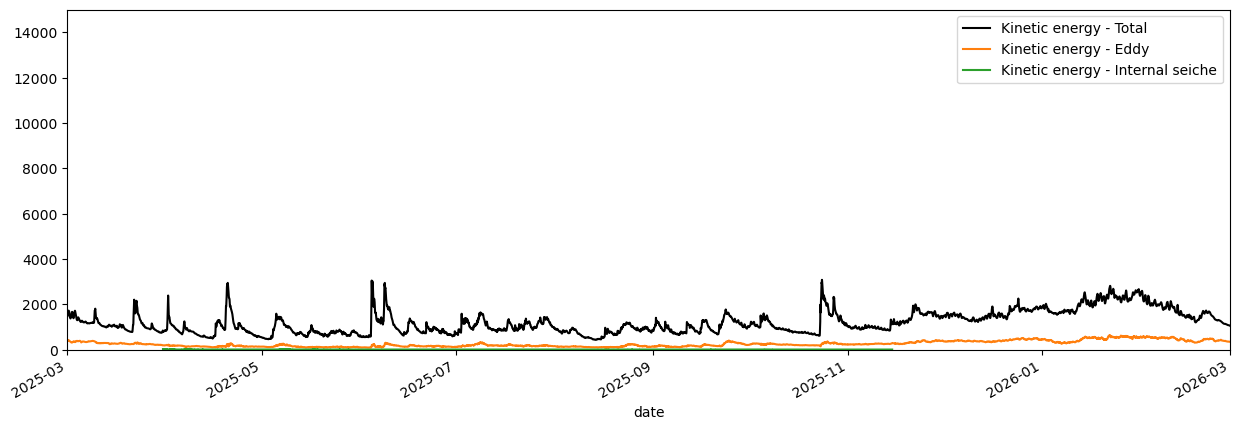

In [97]:
plt.figure(figsize=(15,5))
total_ke.plot(label = 'Kinetic energy - Total', color=plot_colors.ke_color)
eddy_ke.plot(label = 'Kinetic energy - Eddy', color=plot_colors.eddy_color)
seiche_ke.plot(label = 'Kinetic energy - Internal seiche', color=plot_colors.iw_color)
#total_pe.plot(label = 'Available potential energy (APE)', linestyle = '-.', color=plot_colors.pe_color)
#wind_energy_past_day.plot(label = 'Wind energy input', color=plot_colors.wind_color)
#plt.gca().set_xlim(left=pd.to_datetime('2025-07-01'), right=pd.to_datetime('2025-07-05'))
plt.gca().set_xlim(left=pd.to_datetime(start_date), right=pd.to_datetime(end_date))
plt.ylim(0,15000)
plt.legend()

NameError: name 'wind_energy_past_day' is not defined

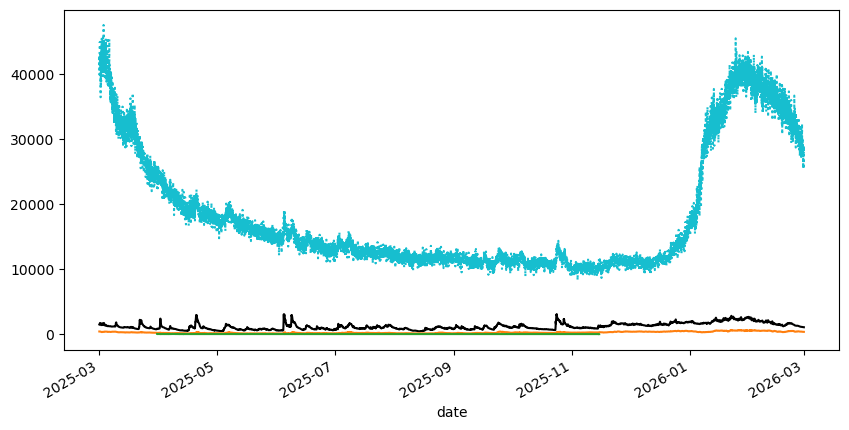

In [98]:
plt.figure(figsize=(10,5))

total_ke.plot(label = 'Kinetic energy - Total', color=plot_colors.ke_color)
eddy_ke.plot(label = 'Kinetic energy - Eddy', color=plot_colors.eddy_color)
seiche_ke.plot(label = 'Kinetic energy - Internal seiche', color=plot_colors.iw_color)
total_pe.plot(label = 'Available potential energy (APE)', linestyle = ':', color=plot_colors.pe_color)
wind_energy_past_day.plot(label = 'Wind energy input - last 24h', linestyle = '--', color=plot_colors.wind_color)

plt.title('Energy budget')
plt.ylabel('Energy [MJ]')
#plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().set_xlim(left=pd.to_datetime(start_date), right=pd.to_datetime(end_date))
plt.gca().set_ylim(0,40000)
plt.xlabel('')
plt.xticks(rotation=90)
plt.legend()
plt.savefig(os.path.join(output_folder, 'budget.png'))

# Fractions

In [18]:
crop_eddy_ke = eddy_ke[(eddy_ke.index > pd.to_datetime(start_date)) & (eddy_ke.index < pd.to_datetime(end_date))]
crop_total_ke = total_ke[(total_ke.index > pd.to_datetime(start_date)) & (total_ke.index < pd.to_datetime(end_date))]
crop_seiche_ke = seiche_ke[(seiche_ke.index > pd.to_datetime(start_date)) & (seiche_ke.index < pd.to_datetime(end_date))]

In [19]:
global_mean_eddy_ratio = 100*crop_eddy_ke.sum()/crop_total_ke.sum()
global_mean_iw_ratio = 100*crop_seiche_ke.sum()/crop_total_ke.sum()

In [20]:
print(global_mean_eddy_ratio)
print(global_mean_iw_ratio)

6.174748002092763
15.506681079635518


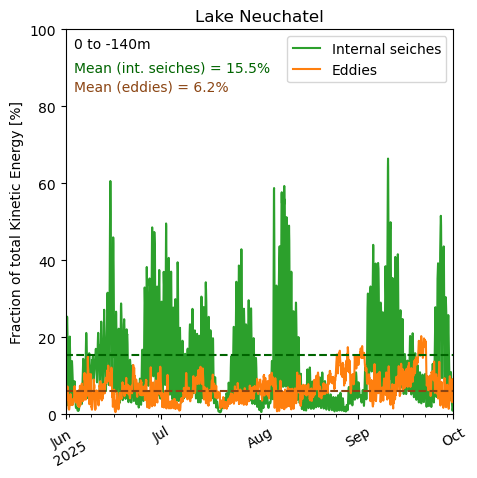

In [21]:
plt.figure(figsize=(5,5))

resample_freq = 'h'
eddy_ke_resample = eddy_ke.resample(resample_freq).mean()
seiche_ke_resample = seiche_ke.resample(resample_freq).mean()
total_ke_resample = total_ke.resample(resample_freq).mean()

ratio_seiche_resample = (100*seiche_ke_resample.add(eddy_ke_resample*0, fill_value=0) / total_ke_resample)
ratio_eddy_resample = (100*eddy_ke_resample / total_ke_resample)

#(100*(eddy_ke_resample.add(seiche_ke_resample, fill_value=0)) / total_ke_resample).plot(label = 'Eddy+Seiche', color=plot_colors.ke_color)
ratio_seiche_resample.plot(label = 'Internal seiches', color=plot_colors.iw_color)
ratio_eddy_resample.plot(label = 'Eddies', color=plot_colors.eddy_color)

plt.hlines(global_mean_iw_ratio,
           eddy_ke_resample.index[0],
           eddy_ke_resample.index[-1],
           linestyles='dashed',
           color='darkgreen')
plt.hlines(global_mean_eddy_ratio,
           eddy_ke_resample.index[0],
           eddy_ke_resample.index[-1],
           linestyles='dashed',
           color='saddlebrown')

plt.text(0.02, 0.98, f'{str_depth_min} to {str_depth_max}m', transform=plt.gca().transAxes, ha='left', va='top')
plt.text(0.02,0.92,f'Mean (int. seiches) = {global_mean_iw_ratio:.1f}%', transform=plt.gca().transAxes, ha='left', va='top', color='darkgreen')
plt.text(0.02,0.87,f'Mean (eddies) = {global_mean_eddy_ratio:.1f}%', transform=plt.gca().transAxes, ha='left', va='top', color='saddlebrown')

plt.gca().set_xlim(left=pd.to_datetime(start_date), right=pd.to_datetime(end_date))

plt.title(f'Lake {lake.capitalize()}')
plt.ylabel('Fraction of total Kinetic Energy [%]')
plt.gca().set_ylim(bottom=0, top=100)
plt.xlabel('')
plt.xticks(rotation=30)
plt.legend()
plt.savefig(os.path.join(output_folder, f'fraction_{resample_freq}.png'))

<Axes: xlabel='date'>

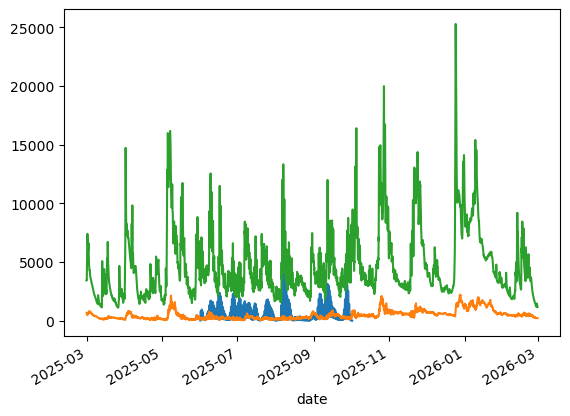

In [15]:
seiche_ke.plot()
eddy_ke.plot()
total_ke.plot()

NameError: name 'total_pe' is not defined

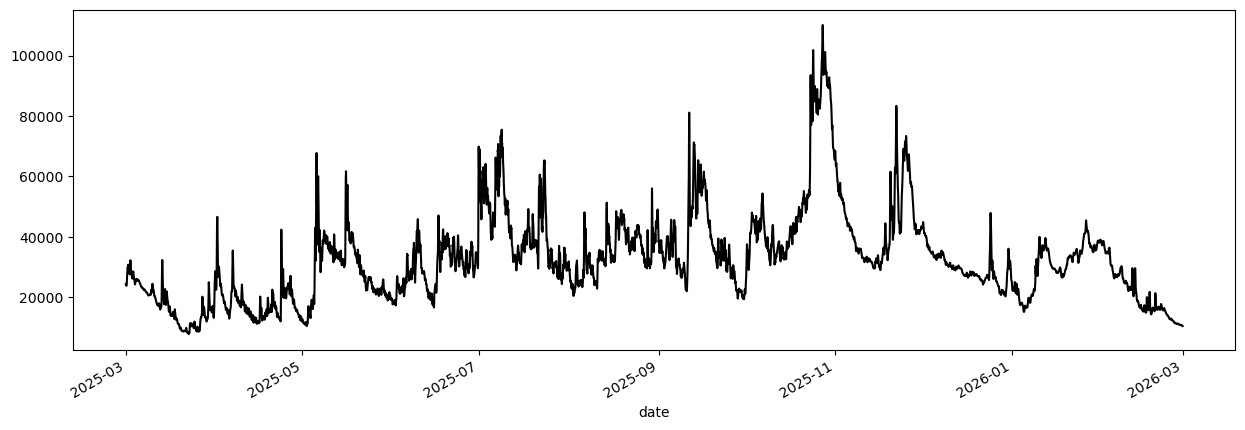

In [16]:
plt.figure(figsize=(15,5))

total_ke.plot(label = 'Kinetic energy - Total', color=plot_colors.ke_color)
total_pe.plot(label = 'Available potential energy (APE)', linestyle = '-', color=plot_colors.pe_color)
(total_pe + total_ke).plot(label = 'Total energy (kinetic + potential)', linestyle = '-', color='tab:purple')
wind_energy_past_day.plot(label = 'Wind energy input - last 24h', linestyle = '--', color=plot_colors.wind_color)

plt.title('Energy budget')
plt.ylabel('Energy [MJ]')
plt.xlabel('')
plt.legend()
plt.savefig(os.path.join(output_folder, 'EP_KE_distrib.png'))

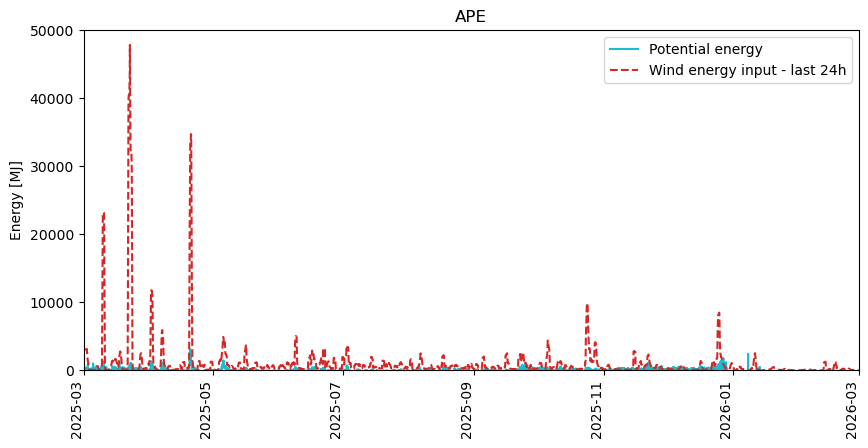

In [18]:
plt.figure(figsize=(10,5))

total_pe.plot(label = 'Potential energy', linestyle = '-', color=plot_colors.pe_color)
wind_energy_past_day.plot(label = 'Wind energy input - last 24h', linestyle = '--', color=plot_colors.wind_color)

plt.title('APE')
plt.ylabel('Energy [MJ]')
#plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().set_xlim(left=pd.to_datetime(start_date), right=pd.to_datetime(end_date))
plt.gca().set_ylim(0,50000)
plt.xlabel('')
plt.xticks(rotation=90)
plt.legend()
plt.savefig(os.path.join(output_folder, 'EP_wind.png'))

# Monthly values 

In [45]:
total_monthly = total_ke.resample('ME').mean()
eddy_monthly = eddy_ke.resample('ME').mean()
seiche_monthly = seiche_ke.resample('ME').mean().add(eddy_monthly*0, fill_value=0)
residual_monthly = total_monthly - eddy_monthly - seiche_monthly

/tmp/ipykernel_131194/4246399410.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Total': np.concatenate([total_monthly[::-1], [total_monthly[-1]]]),  # close loop
/tmp/ipykernel_131194/4246399410.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Seiche': np.concatenate([cum_seiche[::-1], [cum_seiche[-1]]]),
/tmp/ipykernel_131194/4246399410.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Eddy': np.concatenate([eddy_mont

[0.         0.52359878 1.04719755 1.57079633 2.0943951  2.61799388
 3.14159265 3.66519143 4.1887902  4.71238898 5.23598776 5.75958653
 0.        ]


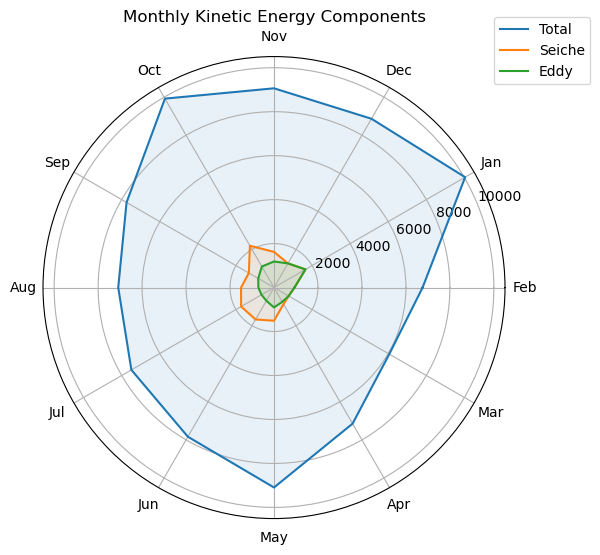

In [83]:
# Example data (replace with yours)

categories = ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']
components = ['Total', 'Eddy', 'Seiche', 'Residual']

cum_seiche = seiche_monthly + eddy_monthly
data = {
    'Total': np.concatenate([total_monthly[::-1], [total_monthly[-1]]]),  # close loop
    'Seiche': np.concatenate([cum_seiche[::-1], [cum_seiche[-1]]]),
    'Eddy': np.concatenate([eddy_monthly[::-1], [eddy_monthly[-1]]]),
}

N = len(categories)

# Angles for radar axes
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  
print(angles)

# Create figure
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# Plot each month
for type, values in data.items():
    values = values + [values[0]]  # close polygon
    ax.plot(angles, values, label=type)
    ax.fill(angles, values, alpha=0.1)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories[::-1])

# Title and legend
plt.title("Monthly Kinetic Energy Components")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()

Text(0.5, 1.0, 'Lake Neuchatel')

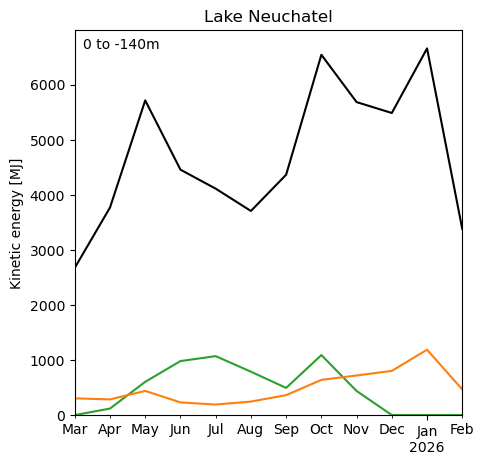

In [84]:
plt.figure(figsize=(5,5))

total_monthly.plot(label = 'Total', color=plot_colors.ke_color)
seiche_monthly.plot(label = 'Internal seiches', color=plot_colors.iw_color)
eddy_monthly.plot(label = 'Eddies', color=plot_colors.eddy_color)

plt.text(0.02, 0.98, f'{str_depth_min} to {str_depth_max}m', transform=plt.gca().transAxes, ha='left', va='top')

plt.ylim(0, None)
plt.ylabel('Kinetic energy [MJ]')
plt.xlabel('')
plt.title(f'Lake {lake.capitalize()}')
#plt.legend()

# Plot hours without wind

In [48]:
eddy_fraction = (100*eddy_ke / total_ke)
seiche_fraction = (100*seiche_ke.add(eddy_ke*0, fill_value=0) / total_ke)

In [49]:
hours_without_wind_arr = []
temp_hours_without_wind = 0
wind_threshold = 1e3
temp_eddy_fraction = eddy_fraction.iloc[0]
eddy_fraction_resetted = []

for i in range(len(wind_energy)):
    if wind_energy.iloc[i] < wind_threshold:
        temp_hours_without_wind += 1
        eddy_fraction_resetted.append(eddy_fraction.iloc[i] - temp_eddy_fraction)
    else:
        temp_hours_without_wind = 0
        eddy_fraction_resetted.append(0)
        temp_eddy_fraction = eddy_fraction.iloc[i]

    hours_without_wind_arr.append(temp_hours_without_wind)

hours_without_wind = pd.Series(hours_without_wind_arr, index=wind_energy.index)
eddy_fraction_reset = pd.Series(eddy_fraction_resetted, index=eddy_fraction.index)

NameError: name 'wind_energy' is not defined

<Axes: xlabel='date'>

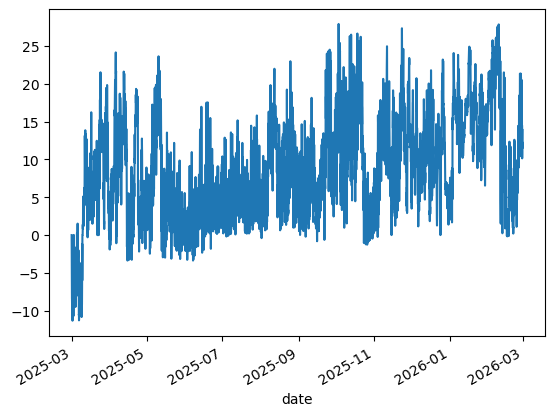

In [26]:
eddy_fraction_reset.plot()

<Axes: xlabel='date'>

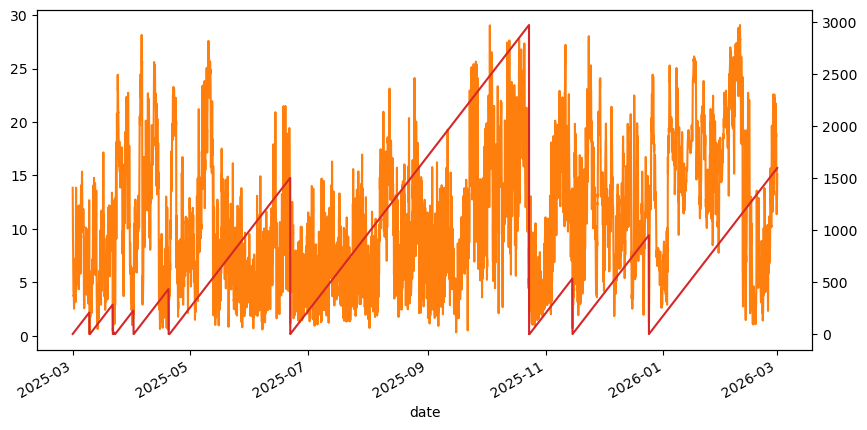

In [27]:
fig, ax= plt.subplots(figsize=(10,5))
eddy_fraction.plot(color=plot_colors.eddy_color)
ax2 = ax.twinx()
hours_without_wind.plot(ax=ax2, color=plot_colors.wind_color)

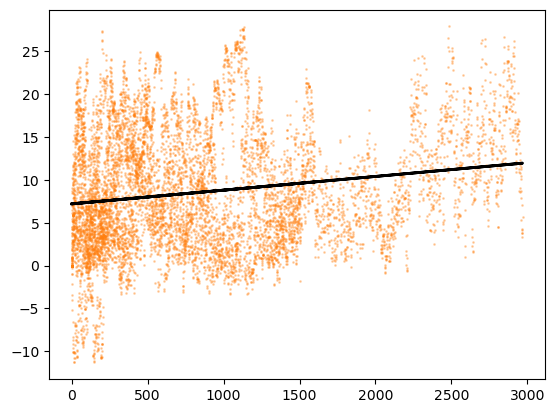

In [28]:
plt.scatter(hours_without_wind, eddy_fraction_reset, s=1, alpha=0.3, label='Eddy fraction', color=plot_colors.eddy_color)


# Linear regression (degree 1 polynomial)
slope, intercept = np.polyfit(hours_without_wind, eddy_fraction_reset, 1)

# Regression line
x_vals = np.array(hours_without_wind)
y_vals = slope * x_vals + intercept

plt.plot(x_vals, y_vals, color='black', linewidth=2, label='Linear fit')



# Bokeh plot

In [50]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

In [51]:
df_eddy_volume = pd.read_csv(
    os.path.join(folder_path, 
                 'outputs_swirl', 
                 'eddy_statistics',
                 'volume_timeserie_upper_layer.csv'), index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '/storage/alplakes_test/neuchatel_100m_2025/outputs_swirl/eddy_statistics/volume_timeserie_upper_layer.csv'

In [16]:
df_eddy_volume.index = pd.to_datetime(df_eddy_volume.index)

In [99]:
# --- Create the base figure (left axis) ---
p = figure(
    title=f'Energy distribution',
    x_axis_type='datetime',
    width=1200,
    height=450,
    x_axis_label='Date',
    y_axis_label='Energy (MJ)',
    tools='xpan,xwheel_zoom,box_zoom,reset,save',
    active_scroll='xwheel_zoom',
)


p.line(x=ratio_seiche_resample.index , y=ratio_seiche_resample, legend_label='Internal Wave KE ratio', line_color=plot_colors.eddy_color)
p.line(x=ratio_eddy_resample.index, y=ratio_eddy_resample, legend_label='Eddy KE ratio', line_color=plot_colors.iw_color)

p.legend.location = 'top_right'
p.legend.click_policy = 'hide'

show(p)


NameError: name 'ratio_seiche_resample' is not defined

In [100]:
cropped_ratio_seiche_resample = ratio_seiche_resample.loc[
    slice(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-12-01"))
]
cropped_ratio_eddy_resample = ratio_eddy_resample.loc[
    slice(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-12-01"))
]

NameError: name 'ratio_seiche_resample' is not defined

In [101]:
plt.scatter(cropped_ratio_seiche_resample.diff().values, cropped_ratio_eddy_resample.diff().values)

NameError: name 'cropped_ratio_seiche_resample' is not defined

In [52]:
for hour_sampling in [12,24,36,48,72]:
    seiche = cropped_ratio_seiche_resample.resample(f'{hour_sampling}h').mean()
    eddy = cropped_ratio_eddy_resample.resample(f'{hour_sampling}h').mean()
    seiche, eddy = seiche.align(eddy, join="inner")

    corr = seiche.corr(eddy)
    print(corr)

NameError: name 'cropped_ratio_seiche_resample' is not defined

In [43]:
for lag in range(-10, 11):
    r = seiche.corr(eddy.shift(lag))
    print(lag, r)

-10 -0.20760233674759587
-9 -0.22228865752348712
-8 -0.2144895804054138
-7 -0.20935215108964636
-6 -0.20280689257977416
-5 -0.2095428164627569
-4 -0.14158740143630058
-3 -0.05215329589438195
-2 -0.02762854439999051
-1 -0.14097170184268198
0 -0.2954096766714146
1 -0.2702170069152379
2 -0.22604176843419857
3 -0.17811614108724227
4 -0.20412399091910302
5 -0.18941614485089353
6 -0.16775160987396606
7 -0.11408786910261047
8 -0.0980369652865883
9 -0.10521702141833682
10 -0.12460597218018789


In [102]:
# --- Create the base figure (left axis) ---
p = figure(
    title=f'Energy distribution',
    x_axis_type='datetime',
    width=1200,
    height=450,
    x_axis_label='Date',
    y_axis_label='Energy (MJ)',
    tools='xpan,xwheel_zoom,box_zoom,reset,save',
    active_scroll='xwheel_zoom',
)


#p.line(x=wind_energy_past_day.index, y=wind_energy_past_day,legend_label='Wind energy', line_color=plot_colors.wind_color)
p.line(x=total_ke.index, y=total_ke, legend_label='KE', line_color=plot_colors.ke_color)
p.line(x=total_pe.index, y=total_pe, legend_label='PE', line_color=plot_colors.pe_color)
#p.line(x=total_ke.index, y=total_ke + total_pe, legend_label='KE + PE', line_color='#800080')
p.line(x=eddy_ke.index, y=eddy_ke, legend_label='Eddy KE', line_color=plot_colors.eddy_color)
p.line(x=seiche_ke.index, y=seiche_ke, legend_label='Internal Wave KE', line_color=plot_colors.iw_color)

p.legend.location = 'top_right'
p.legend.click_policy = 'hide'

show(p)


In [ ]:
import numpy as np
from scipy.signal import correlate, correlation_lags

In [171]:

# Remove NaNs first if necessary
valid = np.isfinite(total_ke) & np.isfinite(eddy_ke)
x_clean = total_ke[valid]
y_clean = eddy_ke[valid]

# Remove means
x_clean = x_clean - np.mean(x_clean)
y_clean = y_clean - np.mean(y_clean)

# Cross-correlation
corr = correlate(y_clean, x_clean, mode="full")
lags = correlation_lags(len(y_clean), len(x_clean), mode="full")

# Normalize
corr = corr / (
    np.std(x_clean) * np.std(y_clean) * len(x_clean)
)

# Lag of maximum correlation
best_lag = lags[np.argmax(corr)]

print("Best lag:", best_lag)
print("Maximum correlation:", np.max(corr))

Best lag: 1
Maximum correlation: 0.6308592912395298


Text(0.02, 0.92, 'Best lag: 1h ')

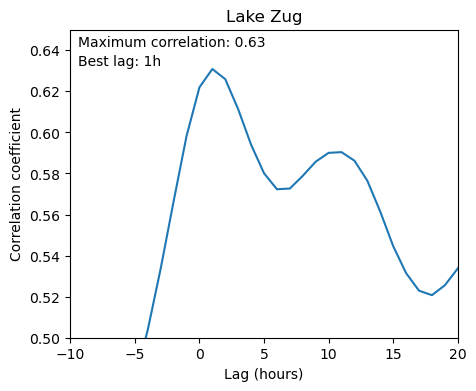

In [176]:
plt.figure(figsize=(5,4))
plt.plot(lags, corr)
plt.xlim(-10, 20)
plt.ylim(0.5,0.65)
plt.title(f'Lake {lake.capitalize()}')
plt.ylabel('Correlation coefficient')
plt.xlabel('Lag (hours)')
plt.text(0.02, 0.98, f'Maximum correlation: {np.max(corr):.2f} ', transform=plt.gca().transAxes, ha='left', va='top')
plt.text(0.02, 0.92, f'Best lag: {best_lag:.0f}h ', transform=plt.gca().transAxes, ha='left', va='top')

# Total energy analysis

In [34]:
P10 = pd.read_csv(os.path.join(folder_path, 'wind_analysis', f'P10.csv'), index_col=0)
P10.index = pd.to_datetime(P10.index)

In [35]:
start_date = '2025-08-05'
end_date = '2025-08-08'

In [36]:
sum_wind_energy_flux = wind_energy[(wind_energy.index>pd.to_datetime(start_date)) & (wind_energy.index<pd.to_datetime(end_date))].sum()
sum_wind_P10 = P10['P10_MJperh'][(P10.index>pd.to_datetime(start_date)) & (P10.index<pd.to_datetime(end_date))].sum()
mean_iw_energy_content = seiche_ke[(seiche_ke.index>pd.to_datetime(start_date)) & (seiche_ke.index<pd.to_datetime(end_date))].mean()
mean_ke_content = total_ke[(total_ke.index>pd.to_datetime(start_date)) & (total_ke.index<pd.to_datetime(end_date))].mean()
mean_pe_content = total_pe[(total_pe.index>pd.to_datetime(start_date)) & (total_pe.index<pd.to_datetime(end_date))].mean()

In [37]:
sum_wind_P10

np.float64(342921.4938677577)

In [38]:
100*6000/sum_wind_P10

np.float64(1.749671603353567)

In [39]:
print(f'Basin-scale internal wave: {round(100*mean_iw_energy_content/sum_wind_P10,4)}% P10')
print(f'Total KE: {round(100*mean_ke_content/sum_wind_P10,4)}% P10')
print(f'Total PE: {round(100*mean_pe_content/sum_wind_P10,4)}% P10')
print(f'Wind RW: {round(100*sum_wind_energy_flux/sum_wind_P10,4)}% P10')

Basin-scale internal wave: 0.0165% P10
Total KE: 0.0549% P10
Total PE: -0.0537% P10
Wind RW: 0.9326% P10


In [ ]:
# Comparison with "Seasonality modulates wind-driven mixing pathways in a large lake" (B. Castro, 2021)
# Entire year
P10_test = 172 # mW/m2
KE_test = 83 # J/m2

P10_test_Jperm2 = P10_test * 86400*365/1e3  # 86400*365=nb of seconds in a year
print(f'Total KE: {round(100*KE_test/P10_test_Jperm2,4)}% P10')